## Script for the statistics of the comparison OneHot vs Internal encoding


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
#setting filepaths the datasets

pi_results_filepath = "output/PI_DataSe_OneHot_vs_Internal_results.csv"
#INI_results_filepath = "./INI_DataSe_results.csv"  INI did not have any results as the threshold are not set by


nnrti_results_filepath = "output/NNRTI_DataSe_OneHot_vs_Internal_results.csv"


nrti_results_filepath = "output/NRTI_DataSe_OneHot_vs_Internal_results.csv"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath]


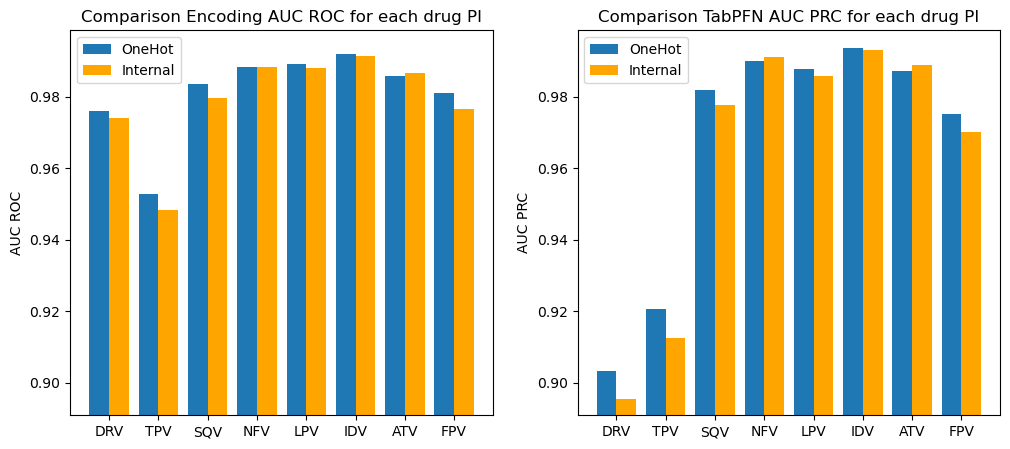

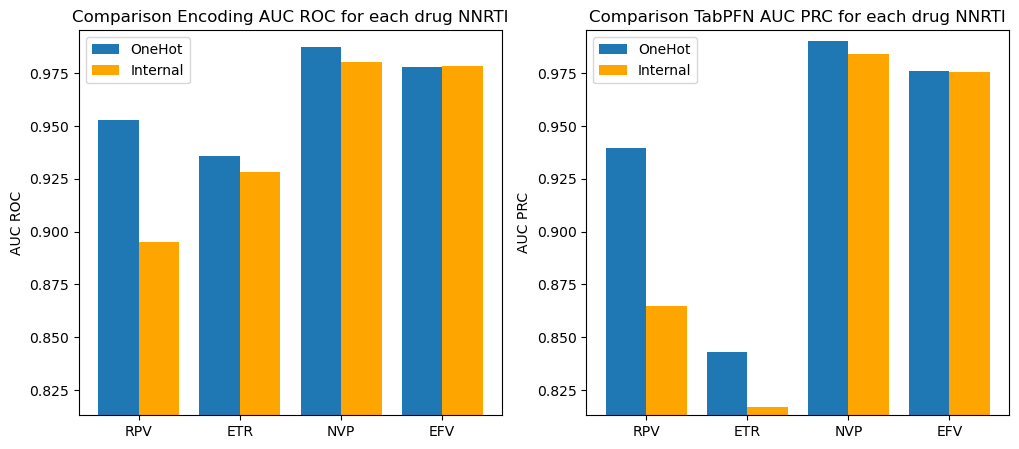

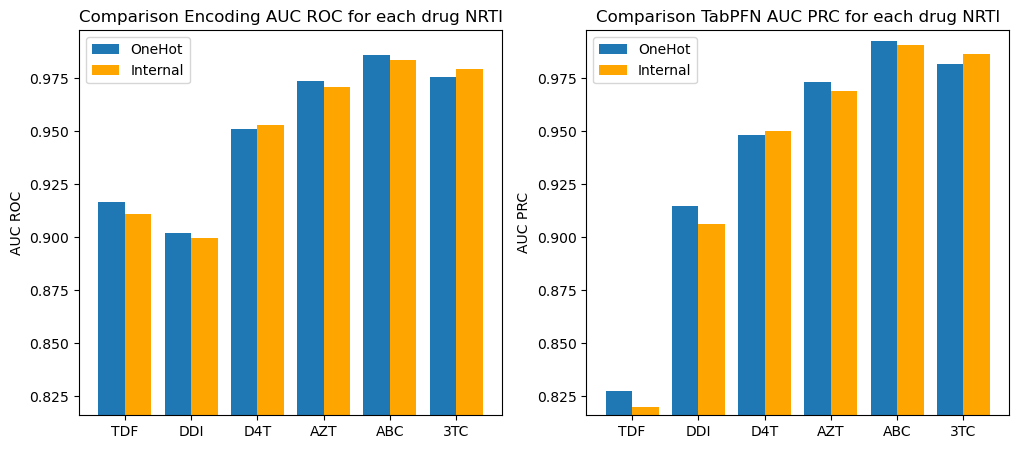

In [3]:


for filepath in filepath_list:
    target = pd.read_csv(filepath)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    #fig.suptitle('Horizontally stacked subplots')

    w, x = 0.4, np.arange(len(target["Drug"]))

    axs[0].bar(x - w/2, target["AUC ROC One Hot"], width=w, label='OneHot')
    axs[0].bar(x + w/2, target["AUC ROC Intrinsic"], width=w, color="orange", label='Internal')

    axs[0].set_xticks(x)
    axs[0].set_xticklabels(target["Drug"])
    axs[0].set_ylabel('AUC ROC')
    axs[0].set_ylim(min(target['AUC ROC One Hot'].min(), target['AUC ROC Intrinsic'].min(), target['AUC PRC One Hot'].min(), target['AUC PRC Intrinsic'].min())* 0.995, min(1.0, max(target['AUC ROC One Hot'].max(), target['AUC ROC Intrinsic'].max(), target['AUC PRC One Hot'].max(), target['AUC PRC Intrinsic'].max())  * 1.005))
    axs[0].set_title('Comparison Encoding AUC ROC for each drug ' + filepath.split("/")[1].split("_")[0])
    axs[0].legend()


    axs[1].bar(x - w/2, target["AUC PRC One Hot"], width=w, label='OneHot')
    axs[1].bar(x + w/2, target["AUC PRC Intrinsic"], width=w, color="orange", label='Internal')

    axs[1].set_xticks(x)
    axs[1].set_xticklabels(target["Drug"])
    axs[1].set_ylabel('AUC PRC')
    axs[1].set_ylim(min(target['AUC ROC One Hot'].min(), target['AUC ROC Intrinsic'].min(), target['AUC PRC One Hot'].min(), target['AUC PRC Intrinsic'].min())* 0.995, min(1.0, max(target['AUC ROC One Hot'].max(), target['AUC ROC Intrinsic'].max(), target['AUC PRC One Hot'].max(), target['AUC PRC Intrinsic'].max())  * 1.005))
    axs[1].set_title('Comparison TabPFN AUC PRC for each drug ' + filepath.split("/")[1].split("_")[0])
    axs[1].legend()


    plt.savefig("figures/" + filepath.split("/")[1].split("_")[0] + "_OneHot_vs_int_Performance.png")


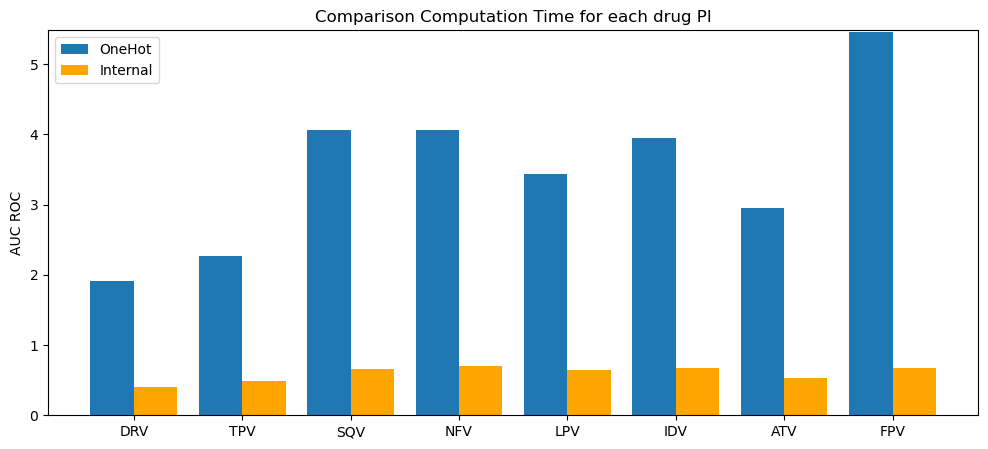

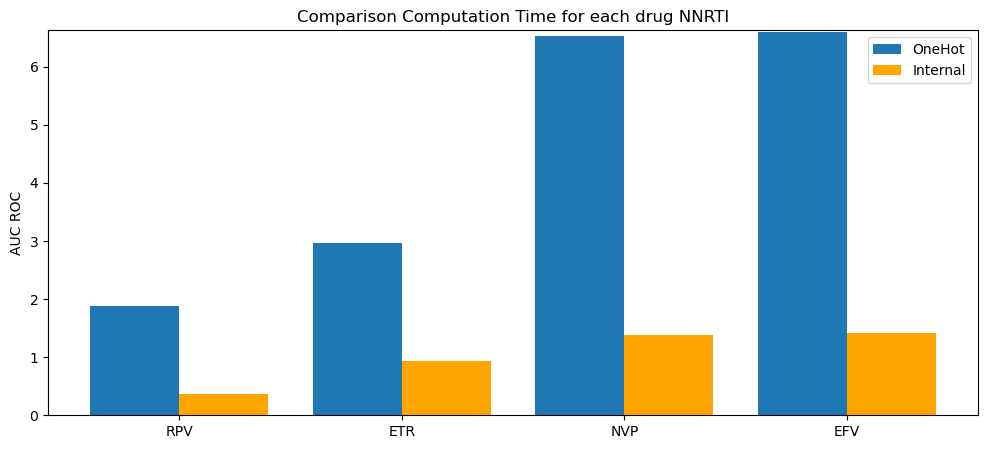

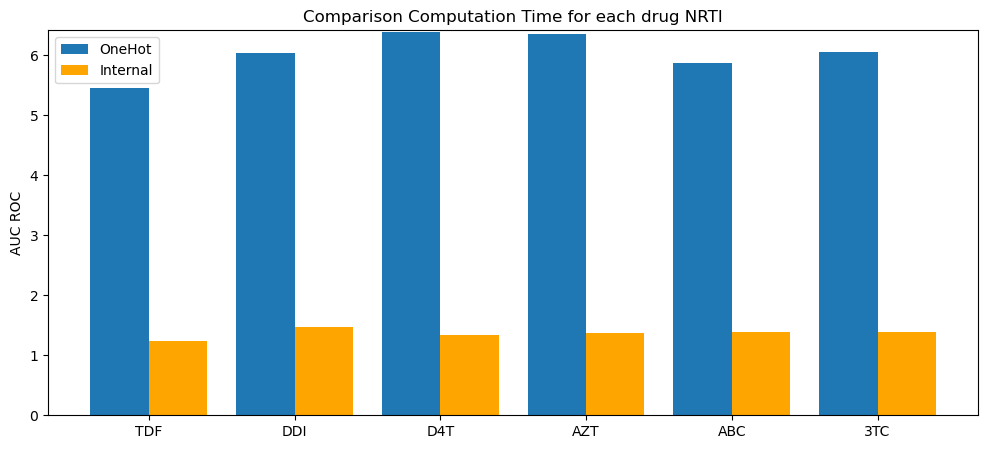

In [4]:


for filepath in filepath_list:
    target = pd.read_csv(filepath)

    fig, ax = plt.subplots(figsize=(12, 5))

    #fig.suptitle('Horizontally stacked subplots')

    w, x = 0.4, np.arange(len(target["Drug"]))

    ax.bar(x - w/2, target["Time One Hot"], width=w, label='OneHot')
    ax.bar(x + w/2, target["Time Intrinsic"], width=w, color="orange", label='Internal')

    ax.set_xticks(x)
    ax.set_xticklabels(target["Drug"])
    ax.set_ylabel('AUC ROC')
    ax.set_ylim(0.0, max(target['Time One Hot'].max(), target['Time Intrinsic'].max())  * 1.005)
    ax.set_title('Comparison Computation Time for each drug ' + filepath.split("/")[1].split("_")[0])
    ax.legend()


    plt.savefig("figures/" + filepath.split("/")[1].split("_")[0] + "_OneHot_vs_Int_time.png")
